# 03 描述統計 — Descriptive Statistics
**Research Question 2: Gender and Current Alcohol Use**

- **Group variable:** `WhatIsYourSex`
- **Response variable:** `CurrentAlcoholUse` (binary after recoding)
- **Method:** Two-proportion z-test

## 1. 載入套件與資料 | Load Libraries & Data

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 載入原始資料 | Load raw data
df = pd.read_csv(r'C:\Users\88690\OneDrive\桌面\project-cycle-3-main\data\Processed\YRBS_2007_cleaned.csv')
print('資料維度 Shape:', df.shape)
df[['WhatIsYourSex', 'CurrentAlcoholUse']].head(10)

資料維度 Shape: (12659, 2)


,WhatIsYourSex,CurrentAlcoholUse
0,1.0,1.0
1,1.0,1.0
2,1.0,1.0
3,1.0,1.0
4,1.0,1.0
5,1.0,2.0
6,1.0,1.0
7,1.0,2.0
8,1.0,1.0
9,1.0,1.0


## 2. 變數探索 | Variable Exploration

In [9]:
# 查看原始編碼分佈 | Check raw value counts
print('=== WhatIsYourSex 原始編碼 ===')
print(df['WhatIsYourSex'].value_counts(dropna=False))

print()
print('=== CurrentAlcoholUse 原始編碼 ===')
print(df['CurrentAlcoholUse'].value_counts(dropna=False))

=== WhatIsYourSex 原始編碼 ===
WhatIsYourSex
1.0    6425
2.0    6234
Name: count, dtype: int64

=== CurrentAlcoholUse 原始編碼 ===
CurrentAlcoholUse
1.0    6942
2.0    2733
3.0    1368
4.0     836
5.0     555
7.0     120
6.0     105
Name: count, dtype: int64


## 3. 資料重編碼 | Recoding

**規則 (按照 Section 6):**
- `WhatIsYourSex`: 1 = Male, 2 = Female → 重編為 `sex_label`
- `CurrentAlcoholUse`: codes 2–7 = success (1, 有喝酒), code 1 = failure (0, 沒喝酒)

In [10]:
# 只保留兩個目標變數，並去除 missing
df_clean = df[['WhatIsYourSex', 'CurrentAlcoholUse']].copy()

# 去除 missing / 無效碼
df_clean = df_clean.dropna(subset=['WhatIsYourSex', 'CurrentAlcoholUse'])

# 只保留有效性別 (1, 2)
df_clean = df_clean[df_clean['WhatIsYourSex'].isin([1, 2])]

# Recode CurrentAlcoholUse → binary (0/1)
# 1 = 沒喝 → 0 (failure)
# 2–7 = 有喝 → 1 (success)
df_clean['alcohol_binary'] = np.where(
    df_clean['CurrentAlcoholUse'].isin([2, 3, 4, 5, 6, 7]), 1, 0
)

# Recode sex → label
df_clean['sex_label'] = df_clean['WhatIsYourSex'].map({1: 'Male', 2: 'Female'})

print('清理後資料維度 Clean shape:', df_clean.shape)
print()
print('sex_label 分佈:')
print(df_clean['sex_label'].value_counts())
print()
print('alcohol_binary 分佈 (0=no, 1=yes):')
print(df_clean['alcohol_binary'].value_counts())

清理後資料維度 Clean shape: (12659, 4)

sex_label 分佈:
sex_label
Male      6425
Female    6234
Name: count, dtype: int64

alcohol_binary 分佈 (0=no, 1=yes):
alcohol_binary
0    6942
1    5717
Name: count, dtype: int64


## 4. 描述統計摘要表 | Descriptive Summary Table

In [11]:
# 分組計算: 樣本數、喝酒人數、比例
summary = (
    df_clean.groupby('sex_label')['alcohol_binary']
    .agg(
        n='count',
        n_yes='sum'
    )
    .assign(
        n_no=lambda x: x['n'] - x['n_yes'],
        proportion=lambda x: (x['n_yes'] / x['n']).round(4),
        percent=lambda x: ((x['n_yes'] / x['n']) * 100).round(2)
    )
)

summary.index.name = 'Sex'
print('=== 描述統計摘要表 | Descriptive Summary Table ===')
print(summary.to_string())

# 計算比例差 (Male - Female)
p_male   = summary.loc['Male',   'proportion']
p_female = summary.loc['Female', 'proportion']
diff = round(p_male - p_female, 4)
print(f'\n比例差 p̂_Male - p̂_Female = {p_male} - {p_female} = {diff}')

=== 描述統計摘要表 | Descriptive Summary Table ===
           n  n_yes  n_no  proportion  percent
Sex                                           
Female  6234   2853  3381      0.4577    45.77
Male    6425   2864  3561      0.4458    44.58

比例差 p̂_Male - p̂_Female = 0.4458 - 0.4577 = -0.0119


## 5. 視覺化 | Visualization
### 5a. Bar Chart — 兩組比例比較

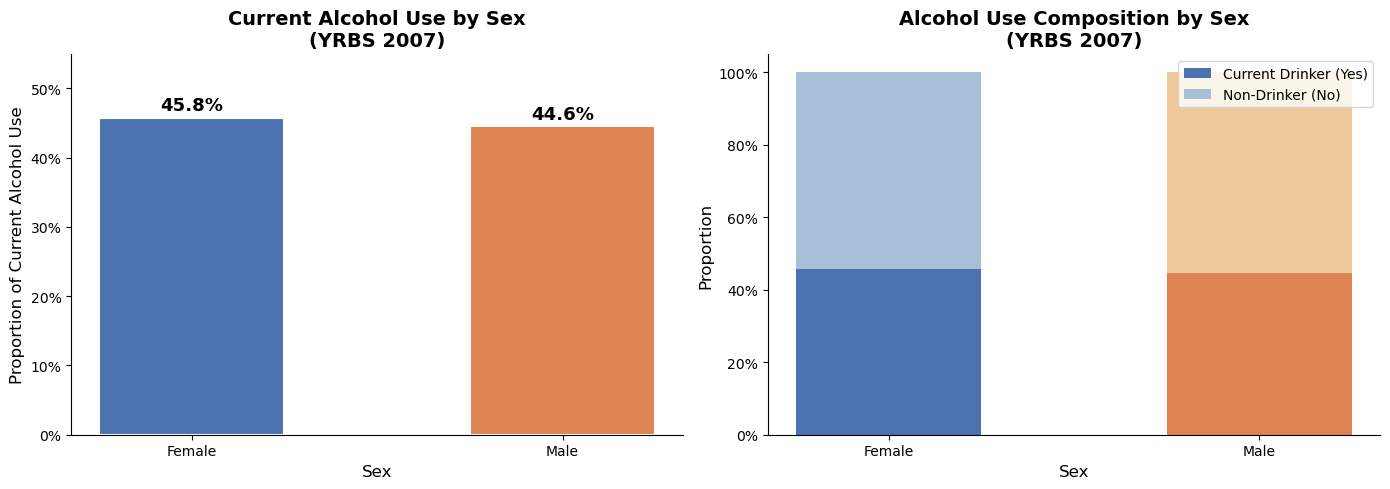

圖表已儲存至 outputs/figures/alcohol_by_sex.png


In [16]:
PROJECT = r'C:\Users\88690\OneDrive\桌面\project-cycle-3-main'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452']
groups = summary.index.tolist()
proportions = summary['proportion'].tolist()

# === 5a. Bar Chart ===
ax = axes[0]
bars = ax.bar(groups, proportions, color=colors, width=0.5, edgecolor='white', linewidth=1.5)

for bar, prop in zip(bars, proportions):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{prop:.1%}',
        ha='center', va='bottom', fontsize=13, fontweight='bold'
    )

ax.set_ylim(0, max(proportions) * 1.2)
ax.set_ylabel('Proportion of Current Alcohol Use', fontsize=12)
ax.set_xlabel('Sex', fontsize=12)
ax.set_title('Current Alcohol Use by Sex\n(YRBS 2007)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.spines[['top', 'right']].set_visible(False)

# === 5b. Stacked Bar Chart ===
ax = axes[1]
p_yes = summary['proportion'].tolist()
p_no  = [1 - p for p in p_yes]

ax.bar(groups, p_yes, color=colors, label='Current Drinker (Yes)', width=0.5)
ax.bar(groups, p_no, bottom=p_yes,
color=['#A8BFD8', '#EFC99A'], label='Non-Drinker (No)', width=0.5)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xlabel('Sex', fontsize=12)
ax.set_title('Alcohol Use Composition by Sex\n(YRBS 2007)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{PROJECT}/outputs/figures/alcohol_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 outputs/figures/alcohol_by_sex.png')

### 5b. Stacked Bar Chart — 各組飲酒 vs 未飲酒比例

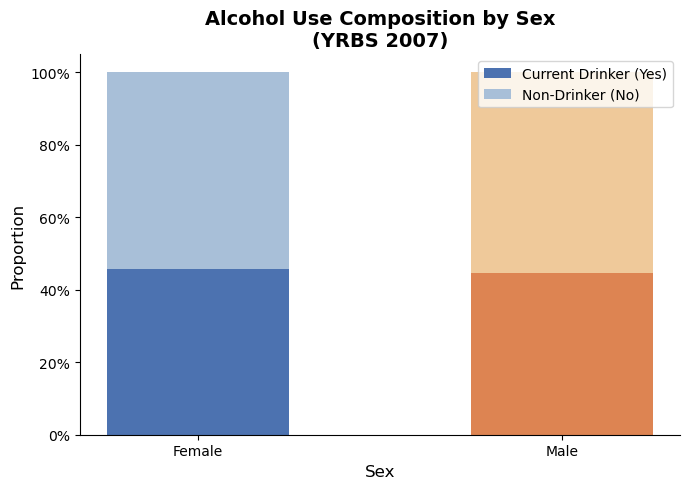

圖表已儲存至 outputs/figures/stacked_bar_alcohol_by_sex.png


In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

p_yes = summary['proportion'].tolist()
p_no  = [1 - p for p in p_yes]

bar1 = ax.bar(groups, p_yes, color=['#4C72B0', '#DD8452'], label='Current Drinker (Yes)', width=0.5)
bar2 = ax.bar(groups, p_no,  bottom=p_yes,
color=['#A8BFD8', '#EFC99A'], label='Non-Drinker (No)', width=0.5)

ax.set_ylim(0, 1.05)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_xlabel('Sex', fontsize=12)
ax.set_title('Alcohol Use Composition by Sex\n(YRBS 2007)', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend(loc='upper right', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\88690\OneDrive\桌面\project-cycle-3-main\outputs\figures\stacked_bar_alcohol_by_sex.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存至 outputs/figures/stacked_bar_alcohol_by_sex.png')

## 6. 儲存摘要表 | Save Summary Table

In [21]:
summary.to_csv(r'C:\Users\88690\OneDrive\桌面\project-cycle-3-main\outputs\tables\descriptive_summary_alcohol_by_sex.csv')
print('摘要表已儲存至 outputs/tables/descriptive_summary_alcohol_by_sex.csv')
print()
print('=== 描述統計完成。下一步: 04_inference.ipynb ===')

摘要表已儲存至 outputs/tables/descriptive_summary_alcohol_by_sex.csv

=== 描述統計完成。下一步: 04_inference.ipynb ===
